In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('superstore_dataset.csv')

In [3]:
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [5]:
df.shape

(9994, 19)

In [6]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
zip              0
city             0
state            0
country          0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [7]:
df.duplicated().sum()

1

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(9993, 19)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9993 non-null   object 
 1   order_date     9993 non-null   object 
 2   ship_date      9993 non-null   object 
 3   customer       9993 non-null   object 
 4   manufactory    9993 non-null   object 
 5   product_name   9993 non-null   object 
 6   segment        9993 non-null   object 
 7   category       9993 non-null   object 
 8   subcategory    9993 non-null   object 
 9   region         9993 non-null   object 
 10  zip            9993 non-null   int64  
 11  city           9993 non-null   object 
 12  state          9993 non-null   object 
 13  country        9993 non-null   object 
 14  discount       9993 non-null   float64
 15  profit         9993 non-null   float64
 16  quantity       9993 non-null   int64  
 17  sales          9993 non-null   float64
 18  profit_margin

In [11]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'zip',
       'city', 'state', 'country', 'discount', 'profit', 'quantity', 'sales',
       'profit_margin'],
      dtype='object')

In [12]:
df = df.drop(columns = ['order_id','manufactory','segment','zip','country'],axis=1)

In [13]:
df.head()

,order_date,ship_date,customer,product_name,category,subcategory,region,city,state,discount,profit,quantity,sales,profit_margin
0,1/3/2019,1/7/2019,Darren Powers,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Office Supplies,Paper,Central,Houston,Texas,0.2,5.5512,2,16.448,0.3375
1,1/4/2019,1/8/2019,Phillina Ober,GBC Standard Plastic Binding Systems Combs,Office Supplies,Binders,Central,Naperville,Illinois,0.8,-5.4870,2,3.540,-1.5500
2,1/4/2019,1/8/2019,Phillina Ober,Avery 508,Office Supplies,Labels,Central,Naperville,Illinois,0.2,4.2717,3,11.784,0.3625
3,1/4/2019,1/8/2019,Phillina Ober,SAFCO Boltless Steel Shelving,Office Supplies,Storage,Central,Naperville,Illinois,0.2,-64.7748,3,272.736,-0.2375
4,1/5/2019,1/12/2019,Mick Brown,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Office Supplies,Art,East,Philadelphia,Pennsylvania,0.2,4.8840,3,19.536,0.2500


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_date     9993 non-null   object 
 1   ship_date      9993 non-null   object 
 2   customer       9993 non-null   object 
 3   product_name   9993 non-null   object 
 4   category       9993 non-null   object 
 5   subcategory    9993 non-null   object 
 6   region         9993 non-null   object 
 7   city           9993 non-null   object 
 8   state          9993 non-null   object 
 9   discount       9993 non-null   float64
 10  profit         9993 non-null   float64
 11  quantity       9993 non-null   int64  
 12  sales          9993 non-null   float64
 13  profit_margin  9993 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 1.1+ MB


## Sales Over Time (Line Chart)

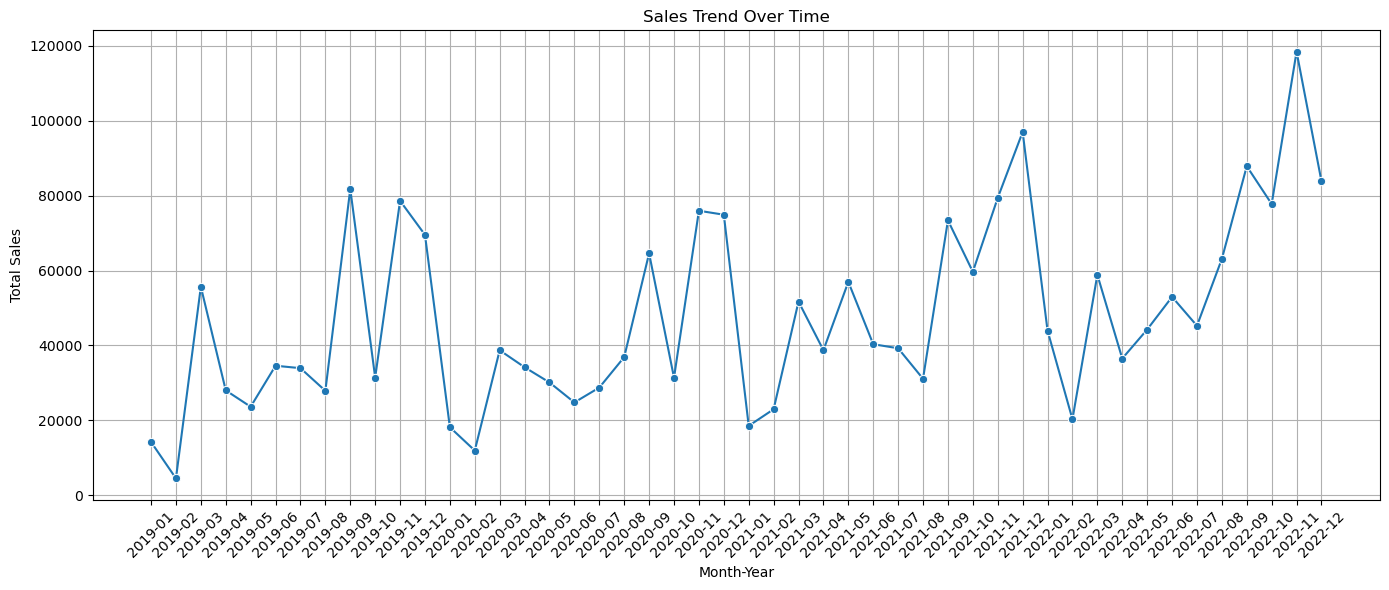

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['YearMonth'] = df['order_date'].dt.to_period('M').astype(str)

sales_trend = df.groupby('YearMonth')['sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=sales_trend, x='YearMonth', y='sales', marker='o')
plt.xticks(rotation=45)
plt.title('Sales Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.grid()
plt.tight_layout()
plt.show()

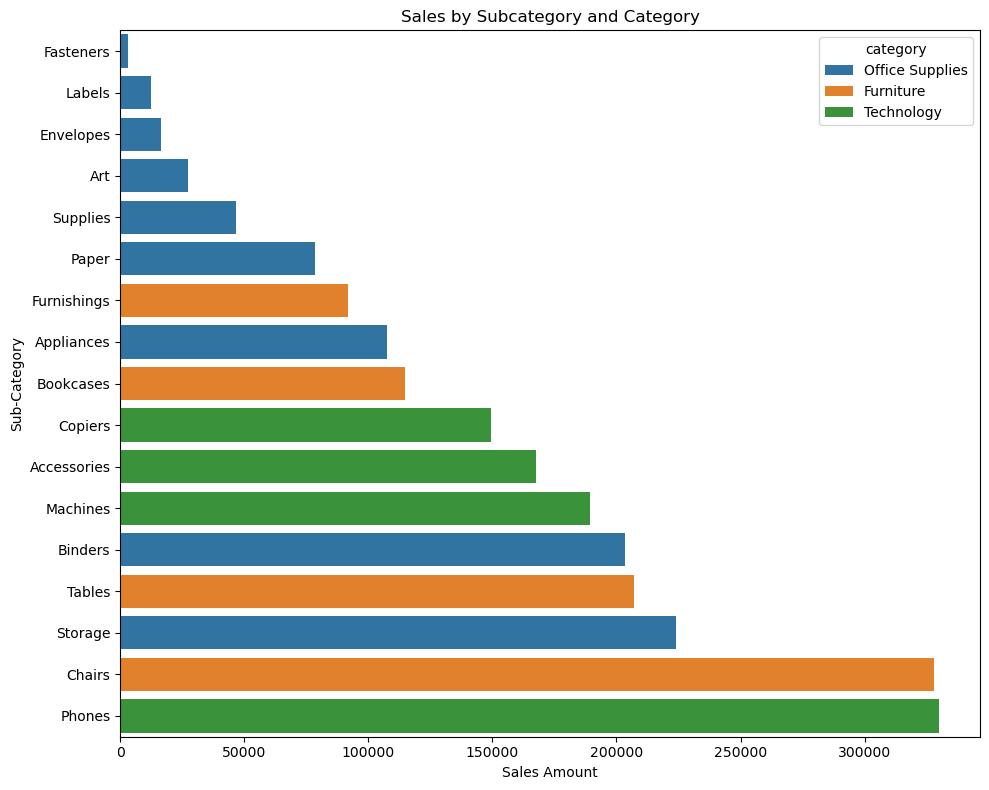

In [17]:
# Category and Subcategory Sales (Horizontal Barplot)
cat_subcat_sales = df.groupby(['category', 'subcategory'])['sales'].sum().sort_values().reset_index()

plt.figure(figsize=(10,8))
sns.barplot(data=cat_subcat_sales, y='subcategory', x='sales', hue='category')
plt.title('Sales by Subcategory and Category')
plt.xlabel('Sales Amount')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()


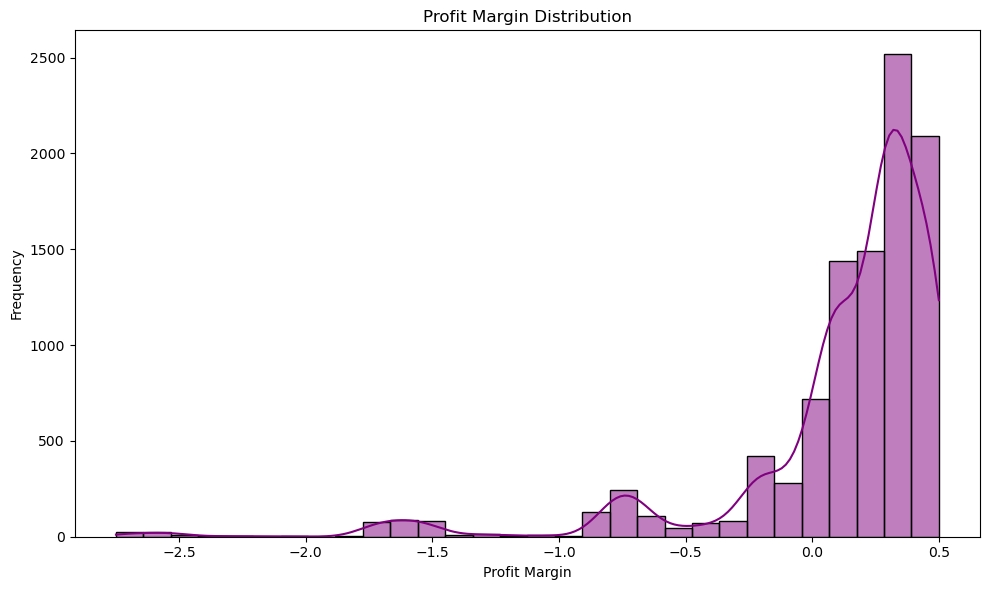

In [18]:
# 3. Profit Margin Distribution (Histogram + KDE)

plt.figure(figsize=(10,6))
sns.histplot(df['profit_margin'], kde=True, bins=30, color='purple')
plt.title('Profit Margin Distribution')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



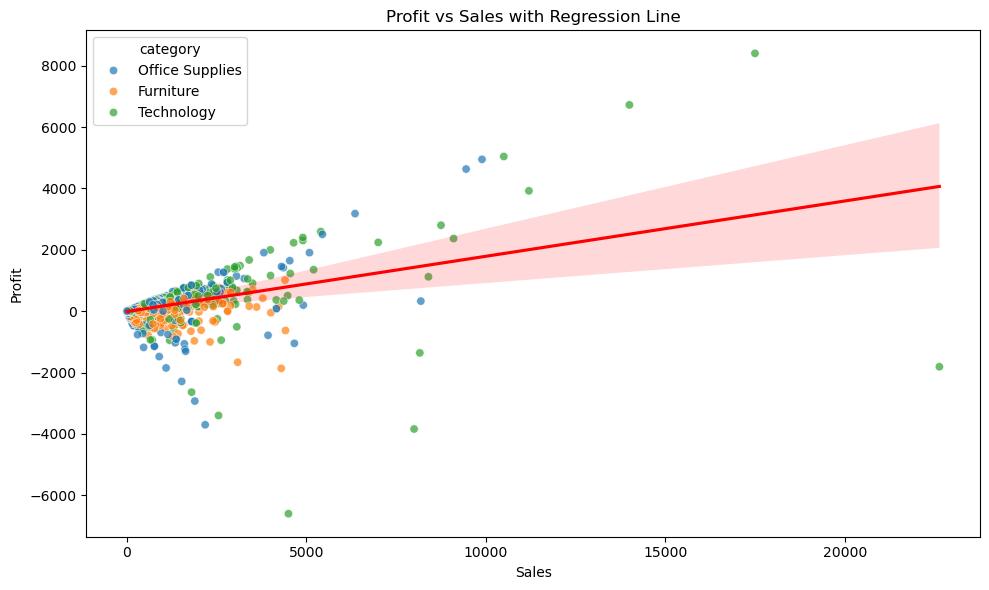

In [19]:
#Advanced EDA Graphs:
#4. Profit vs Sales (Scatter Plot + Regression Line)
# To see the relationship between sales and profitability.
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sales', y='profit', hue='category', alpha=0.7)
sns.regplot(data=df, x='sales', y='profit', scatter=False, color='red')
plt.title('Profit vs Sales with Regression Line')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


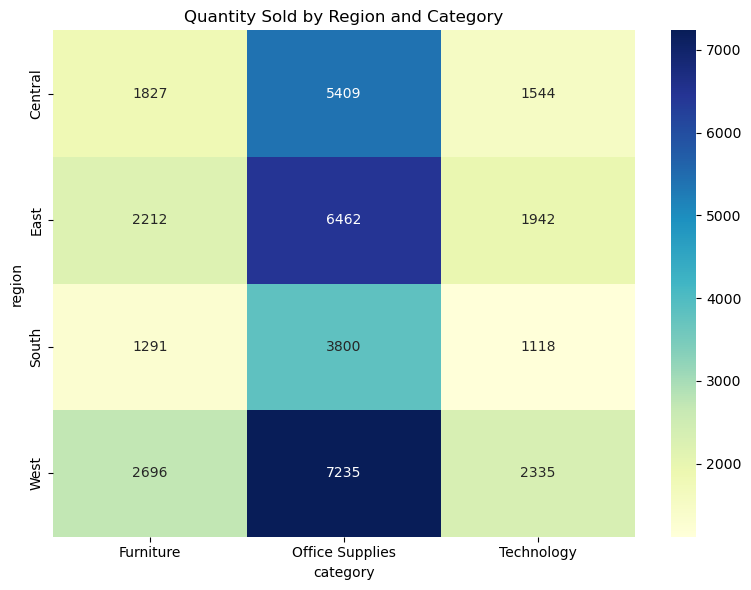

In [20]:
# 5. Heatmap: Quantity Sold Across Region and Category
pivot = df.pivot_table(index='region', columns='category', values='quantity', aggfunc='sum')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".0f")
plt.title('Quantity Sold by Region and Category')
plt.tight_layout()
plt.show()



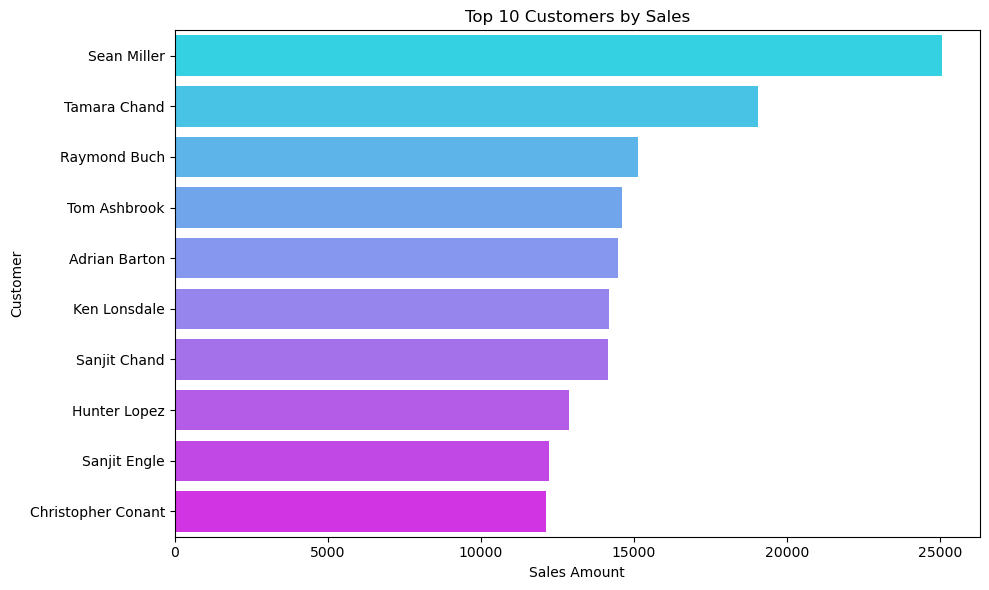

In [21]:
## Deep & Beautiful Visualizations:

top_customers = df.groupby('customer')['sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='sales', y='customer', palette='cool')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()
